# Velvetfruit Extract Vouchers (VEV) -- Quant Research Notebook
### European-Style Options | Fixed TTE = 7 Days | Strikes: 4000-6500

---

**Purpose:** Exploratory data analysis and signal extraction for the VEV options trading competition.  
**Data:** 3 days of L3 order-book snapshots (`prices_round_3_day_X.csv`) and executed trades (`trades_round_3_day_X.csv`).  
**Underlying:** `VELVETFRUIT_EXTRACT` (spot ~ 5,250 at Day 0 open).

---

## Analysis Roadmap

1. **Data Overview** -- schema, coverage, timestamp grid, product inventory  
2. **Data Cleaning & Validation** -- missing levels, timestamp regularity, outlier detection  
3. **Market Microstructure** -- bid-ask spreads, order-book depth, liquidity by strike  
4. **Cross-Strike Pricing Analysis** -- intrinsic-value floors, convexity, butterfly positivity  
5. **Underlying Price Dynamics** -- realized vol, drift, intraday patterns  
6. **Implied Volatility Surface** -- Black-Scholes IV per strike per day, smile & skew  
7. **Time Dynamics & Theta Decay** -- TTE effects across 3 days  
8. **Trade Flow Analysis** -- counterparty activity, clustering, market impact  
9. **Preliminary Strategy Insights** -- mispricings, vol-edge opportunities, liquidity arb

---
## 1. Data Overview

We begin by loading all six data files, combining them, and inspecting the schema and coverage.
Key things to confirm:
- Are timestamps evenly spaced? (expected: every 100 units, 0-999,900 -> 10,000 ticks/day)
- Are all 10 strikes present on all days?
- Is the underlying (`VELVETFRUIT_EXTRACT`) recorded consistently?

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
from scipy.stats import norm
from scipy.optimize import brentq

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid', palette='tab10')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (14, 5), 'font.size': 11})

DATA_DIR = '/Users/felixyu/Downloads/ROUND_3'
DAYS     = [0, 1, 2]
STRIKES  = [4000, 4500, 5000, 5100, 5200, 5300, 5400, 5500, 6000, 6500]
VEV_COLS = ['VEV_' + str(k) for k in STRIKES]

# Load prices
price_frames = []
for d in DAYS:
    df = pd.read_csv(f'{DATA_DIR}/prices_round_3_day_{d}.csv', sep=';')
    price_frames.append(df)
prices_raw = pd.concat(price_frames, ignore_index=True)

# Load trades
trade_frames = []
for d in DAYS:
    df = pd.read_csv(f'{DATA_DIR}/trades_round_3_day_{d}.csv', sep=';')
    df['day'] = d
    trade_frames.append(df)
trades_raw = pd.concat(trade_frames, ignore_index=True)

print('=== PRICES RAW ===')
print(prices_raw.shape)
display(prices_raw.head(3))
print()
print('=== TRADES RAW ===')
print(trades_raw.shape)
display(trades_raw.head(3))

=== PRICES RAW ===
(360000, 17)


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,0,0,VEV_5400,22,25,NaN,NaN,NaN,NaN,24,25,NaN,NaN,NaN,NaN,23.0,0.0
1,0,0,VEV_6500,0,16,NaN,NaN,NaN,NaN,1,16,NaN,NaN,NaN,NaN,0.5,0.0
2,0,0,VEV_5500,8,25,NaN,NaN,NaN,NaN,9,25,NaN,NaN,NaN,NaN,8.5,0.0



=== TRADES RAW ===
(4048, 8)


,timestamp,buyer,seller,symbol,currency,price,quantity,day
0,2500,NaN,NaN,VELVETFRUIT_EXTRACT,XIRECS,5250.0,4,0
1,2900,NaN,NaN,VEV_5400,XIRECS,22.0,3,0
2,2900,NaN,NaN,VEV_5500,XIRECS,8.0,3,0


In [3]:
# Coverage check
print('Products in prices data:')
print(sorted(prices_raw['product'].unique()))

print('\nTimestamp range per day:')
for d in DAYS:
    sub = prices_raw[prices_raw['day'] == d]
    ts = sub['timestamp']
    step_ok = ts.nunique() == 10000
    print(f'  Day {d}: min={ts.min()}, max={ts.max()}, '
          f'n_unique={ts.nunique()}, step_check={"OK" if step_ok else "ANOMALY"}')

print('\nRow counts per (day, product):')
counts = prices_raw.groupby(['day', 'product']).size().unstack(fill_value=0)
print(counts.to_string())

Products in prices data:
['HYDROGEL_PACK', 'VELVETFRUIT_EXTRACT', 'VEV_4000', 'VEV_4500', 'VEV_5000', 'VEV_5100', 'VEV_5200', 'VEV_5300', 'VEV_5400', 'VEV_5500', 'VEV_6000', 'VEV_6500']

Timestamp range per day:
  Day 0: min=0, max=999900, n_unique=10000, step_check=OK
  Day 1: min=0, max=999900, n_unique=10000, step_check=OK
  Day 2: min=0, max=999900, n_unique=10000, step_check=OK

Row counts per (day, product):
product  HYDROGEL_PACK  VELVETFRUIT_EXTRACT  VEV_4000  VEV_4500  VEV_5000  VEV_5100  VEV_5200  VEV_5300  VEV_5400  VEV_5500  VEV_6000  VEV_6500
day                                                                                                                                            
0                10000                10000     10000     10000     10000     10000     10000     10000     10000     10000     10000     10000
1                10000                10000     10000     10000     10000     10000     10000     10000     10000     10000     10000     10000
2     

---
## 2. Data Cleaning & Validation

Key steps:
- Separate the underlying from the options
- Compute best bid/ask (level 1) and mid-price
- Compute bid-ask spread and relative spread
- Add a global time index for cross-day continuity
- Validate that no option trades below intrinsic value

In [4]:
# Build clean option book
opt = prices_raw[prices_raw['product'].isin(VEV_COLS)].copy()
opt['strike']     = opt['product'].str.extract(r'(\d+)').astype(int)
opt['global_ts']  = opt['day'] * 1_000_000 + opt['timestamp']
opt['spread']     = opt['ask_price_1'] - opt['bid_price_1']
opt['rel_spread'] = opt['spread'] / opt['mid_price'].replace(0, np.nan)
opt = opt.sort_values(['product', 'global_ts']).reset_index(drop=True)

# Build clean underlying series
und = prices_raw[prices_raw['product'] == 'VELVETFRUIT_EXTRACT'].copy()
und['global_ts'] = und['day'] * 1_000_000 + und['timestamp']
und = und.sort_values('global_ts').reset_index(drop=True)
und.rename(columns={'mid_price': 'spot'}, inplace=True)

print(f'Option rows:     {len(opt):,}')
print(f'Underlying rows: {len(und):,}')
print()
print('Sample cleaned option data:')
display(opt[['day','timestamp','strike','bid_price_1','ask_price_1',
             'mid_price','spread','rel_spread']].head(8))

Option rows:     300,000
Underlying rows: 30,000

Sample cleaned option data:


,day,timestamp,strike,bid_price_1,ask_price_1,mid_price,spread,rel_spread
0,0,0,4000,1240,1260,1250.0,20,0.016000
1,0,100,4000,1240,1261,1250.5,21,0.016793
2,0,200,4000,1240,1261,1250.5,21,0.016793
3,0,300,4000,1240,1261,1250.5,21,0.016793
4,0,400,4000,1240,1261,1250.5,21,0.016793
5,0,500,4000,1239,1260,1249.5,21,0.016807
6,0,600,4000,1238,1259,1248.5,21,0.016820
7,0,700,4000,1238,1259,1248.5,21,0.016820


In [5]:
# Validate intrinsic value floor: call price >= max(S - K, 0)
opt_merged = opt.merge(
    und[['day','timestamp','spot']],
    on=['day','timestamp'],
    how='left'
)
opt_merged['intrinsic']  = (opt_merged['spot'] - opt_merged['strike']).clip(lower=0)
opt_merged['time_value'] = (opt_merged['mid_price'] - opt_merged['intrinsic']).clip(lower=0)
opt_merged['floor_viol'] = opt_merged['mid_price'] < opt_merged['intrinsic'] - 0.5

violations = opt_merged[opt_merged['floor_viol']]
print(f'Intrinsic-value floor violations: {len(violations)}')
if len(violations):
    display(violations[['day','timestamp','strike','mid_price','intrinsic']].head(20))
else:
    print('-> No violations. Option prices satisfy the no-arb intrinsic floor.')

Intrinsic-value floor violations: 2568


,day,timestamp,strike,mid_price,intrinsic
10,0,1000,4000,1246.5,1247.5
29,0,2900,4000,1241.0,1246.5
58,0,5800,4000,1237.5,1239.0
86,0,8600,4000,1229.5,1230.5
92,0,9200,4000,1231.5,1233.0
125,0,12500,4000,1237.5,1238.5
126,0,12600,4000,1238.5,1239.5
137,0,13700,4000,1240.5,1242.0
152,0,15200,4000,1238.0,1243.5
154,0,15400,4000,1242.5,1243.5


In [6]:
# Call spread monotonicity: C(K1) >= C(K2) for K1 < K2
pivot = opt_merged.pivot_table(index=['day','timestamp'], columns='strike', values='mid_price')
pivot = pivot.sort_index(axis=1)

mono_viol = 0
for i in range(len(STRIKES)-1):
    k1, k2 = STRIKES[i], STRIKES[i+1]
    if k1 in pivot.columns and k2 in pivot.columns:
        bad = (pivot[k1] < pivot[k2] - 0.5).sum()
        if bad > 0:
            print(f'  Monotonicity violated: C({k1}) < C({k2}) at {bad} timestamps')
            mono_viol += bad

if mono_viol == 0:
    print('-> Call prices are monotonically decreasing in strike at all timestamps. OK')

# Butterfly positivity check
print('\nButterfly spread checks (convexity - should be >= 0):')
bfly_viols = {}
for i in range(1, len(STRIKES)-1):
    km, k0, kp = STRIKES[i-1], STRIKES[i], STRIKES[i+1]
    if all(k in pivot.columns for k in [km, k0, kp]):
        bfly = pivot[km] - 2*pivot[k0] + pivot[kp]
        n_neg = (bfly < -0.5).sum()
        bfly_viols[(km, k0, kp)] = n_neg
        flag = ' <- POTENTIAL ARBI' if n_neg > 0 else ' OK'
        print(f'  Butterfly ({km},{k0},{kp}): {n_neg} negative timestamps{flag}')

-> Call prices are monotonically decreasing in strike at all timestamps. OK

Butterfly spread checks (convexity - should be >= 0):
  Butterfly (4000,4500,5000): 0 negative timestamps OK
  Butterfly (4500,5000,5100): 0 negative timestamps OK
  Butterfly (5000,5100,5200): 0 negative timestamps OK
  Butterfly (5100,5200,5300): 0 negative timestamps OK
  Butterfly (5200,5300,5400): 0 negative timestamps OK
  Butterfly (5300,5400,5500): 0 negative timestamps OK
  Butterfly (5400,5500,6000): 0 negative timestamps OK
  Butterfly (5500,6000,6500): 0 negative timestamps OK


**Interpretation:** Butterfly spread violations (C(K-d) - 2*C(K) + C(K+d) < 0) imply
that the middle strike is *overpriced* relative to the wings -- a tradeable arbitrage:
sell the butterfly (sell wings, buy 2x middle). Flag persistent violations for deeper investigation.

---
## 3. Market Microstructure Analysis

Liquidity varies dramatically across strikes. Understanding which strikes are liquid matters for:
- Determining execution costs for any strategy
- Identifying which strikes can be *traded* vs. only *observed*
- Spotting structural illiquidity that may cause persistent mispricings

In [7]:
# Bid-ask spread statistics by strike
spread_stats = opt.groupby('strike')['spread'].agg(['mean','median','std','min','max'])
rel_stats = opt.groupby('strike')['rel_spread'].agg(['mean','median'])
rel_stats.columns = ['rel_mean','rel_median']
liq_summary = spread_stats.join(rel_stats)
liq_summary.columns = ['Spread Mean','Spread Median','Spread Std',
                        'Spread Min','Spread Max','Rel Mean','Rel Median']

print('=== Bid-Ask Spread Statistics by Strike ===')
print(liq_summary.round(4).to_string())

=== Bid-Ask Spread Statistics by Strike ===
        Spread Mean  Spread Median  Spread Std  Spread Min  Spread Max  Rel Mean  Rel Median
strike                                                                                      
4000        20.8135           21.0      1.4816           9          22    0.0166      0.0168
4500        15.8527           16.0      1.1889           7          17    0.0211      0.0213
5000         6.0433            6.0      0.6463           2           7    0.0237      0.0239
5100         4.2958            4.0      0.5795           1           6    0.0258      0.0258
5200         2.8881            3.0      0.4432           1           4    0.0303      0.0305
5300         2.1068            2.0      0.3904           1           3    0.0455      0.0435
5400         1.3814            1.0      0.4857           1           2    0.0900      0.0800
5500         1.1498            1.0      0.3568           1           2    0.1859      0.1538
6000         1.0000       

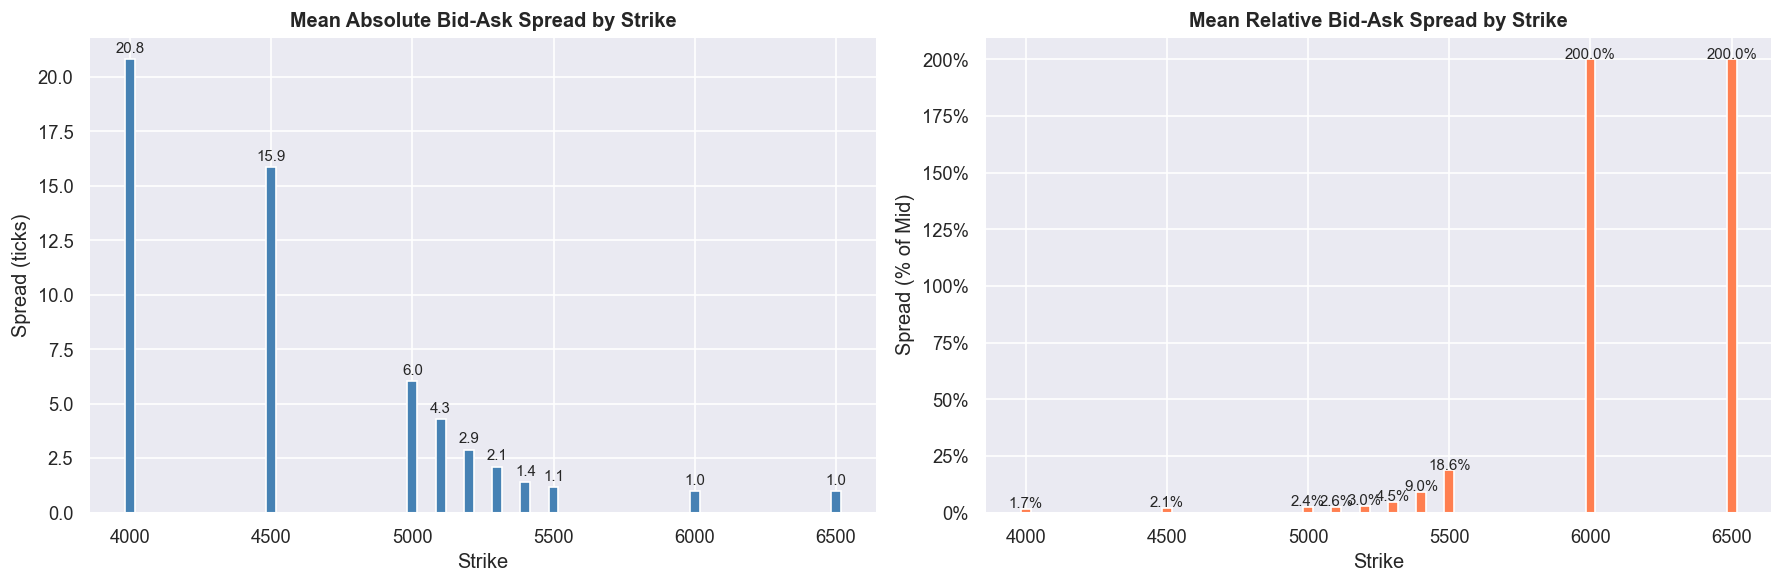

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].bar(liq_summary.index, liq_summary['Spread Mean'],
            color='steelblue', edgecolor='white', width=35)
axes[0].set_title('Mean Absolute Bid-Ask Spread by Strike', fontweight='bold')
axes[0].set_xlabel('Strike'); axes[0].set_ylabel('Spread (ticks)')
for k, v in liq_summary['Spread Mean'].items():
    axes[0].text(k, v + 0.3, f'{v:.1f}', ha='center', fontsize=9)

axes[1].bar(liq_summary.index, liq_summary['Rel Mean']*100,
            color='coral', edgecolor='white', width=35)
axes[1].set_title('Mean Relative Bid-Ask Spread by Strike', fontweight='bold')
axes[1].set_xlabel('Strike'); axes[1].set_ylabel('Spread (% of Mid)')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
for k, v in liq_summary['Rel Mean'].items():
    axes[1].text(k, v*100 + 0.5, f'{v*100:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

**KEY INSIGHT:** Absolute spreads are wider for deep-ITM options (large premium), but
*relative* spreads reveal the true execution cost.
Far OTM options (K=6000, K=6500) have bid=0 / ask=1, giving a ~200% relative spread --
effectively untradeable at fair value without first having a directional view.
Near-ATM options (K=5000-5300) offer the best liquidity-to-signal ratio.

=== Order Book Depth by Strike (L1 Average) ===
        Avg Bid Vol (L1)  Avg Ask Vol (L1)
strike                                    
4000               10.92             10.92
4500                8.95              8.95
5000               15.33             15.48
5100               19.25             19.35
5200               22.56             22.51
5300               20.28             20.24
5400               21.76             21.72
5500               22.18             22.17
6000               22.48             22.48
6500               15.48             15.48


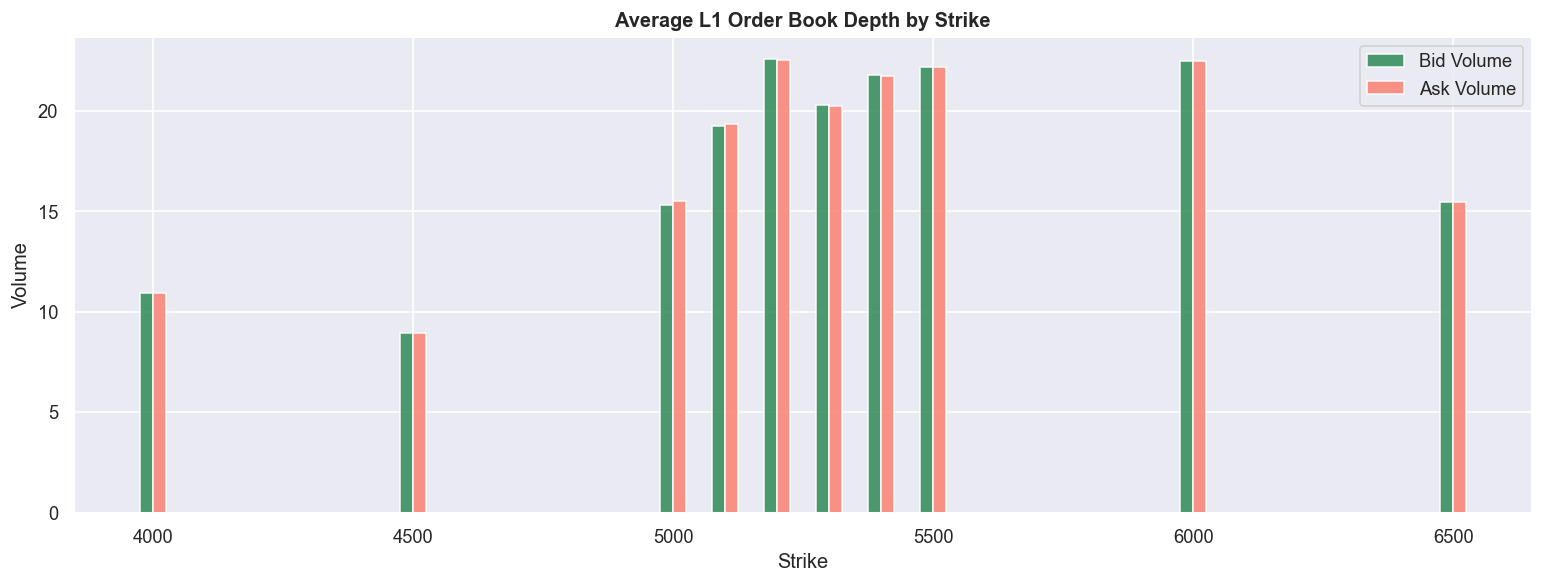

In [9]:
# Order book depth: average total volume at L1
opt['total_bid_vol'] = opt['bid_volume_1'].fillna(0)
opt['total_ask_vol'] = opt['ask_volume_1'].fillna(0)

depth_by_strike = opt.groupby('strike')[['total_bid_vol','total_ask_vol']].mean()
depth_by_strike.columns = ['Avg Bid Vol (L1)', 'Avg Ask Vol (L1)']

print('=== Order Book Depth by Strike (L1 Average) ===')
print(depth_by_strike.round(2).to_string())

fig, ax = plt.subplots(figsize=(13, 5))
width = 25
x = np.array(STRIKES)
ax.bar(x - width/2, depth_by_strike['Avg Bid Vol (L1)'],
       width=width, label='Bid Volume', color='seagreen', alpha=0.85)
ax.bar(x + width/2, depth_by_strike['Avg Ask Vol (L1)'],
       width=width, label='Ask Volume', color='salmon', alpha=0.85)
ax.set_title('Average L1 Order Book Depth by Strike', fontweight='bold')
ax.set_xlabel('Strike'); ax.set_ylabel('Volume')
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation:** Roughly symmetric bid/ask volumes across all strikes
strongly suggests a **single market-maker** quoting both sides simultaneously.
This is consistent with the XIRECS counterparty appearing in virtually every trade.
Asymmetry between bid and ask volume at any strike would indicate directional positioning.

---
## 4. Cross-Strike Pricing Analysis

For European calls, theory requires:
- **Monotonically decreasing** in strike: C(K1) >= C(K2) when K1 < K2
- **Convex** in strike: butterfly spread >= 0
- **Below the spot**: call <= S
- **Above intrinsic**: call >= max(S-K, 0)

We also decompose each price into **intrinsic value + time value**.

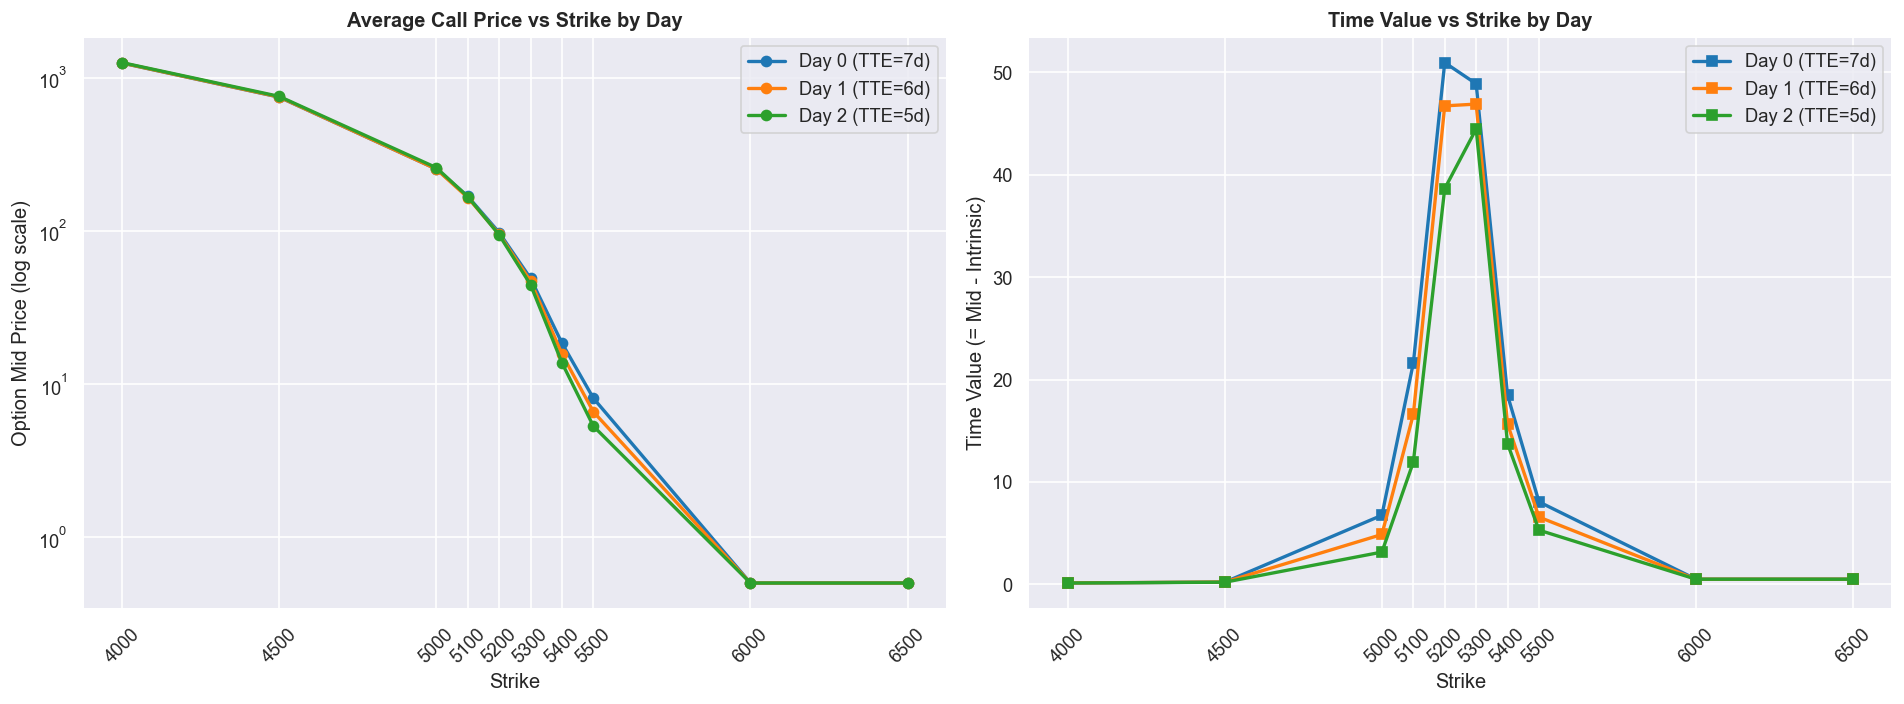

In [10]:
# Average mid-price and time value per (day, strike)
avg_by_day = opt_merged.groupby(['day','strike']).agg(
    mid=('mid_price','mean'),
    intrinsic=('intrinsic','mean'),
    time_value=('time_value','mean')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: absolute price (log scale)
for d in DAYS:
    sub = avg_by_day[avg_by_day['day'] == d]
    axes[0].plot(sub['strike'], sub['mid'], marker='o',
                 label=f'Day {d} (TTE={7-d}d)', linewidth=2)
axes[0].set_title('Average Call Price vs Strike by Day', fontweight='bold')
axes[0].set_xlabel('Strike'); axes[0].set_ylabel('Option Mid Price (log scale)')
axes[0].legend(); axes[0].set_yscale('log')
axes[0].set_xticks(STRIKES); axes[0].tick_params(axis='x', rotation=45)

# Right: time value only
for d in DAYS:
    sub = avg_by_day[avg_by_day['day'] == d]
    axes[1].plot(sub['strike'], sub['time_value'], marker='s',
                 label=f'Day {d} (TTE={7-d}d)', linewidth=2)
axes[1].set_title('Time Value vs Strike by Day', fontweight='bold')
axes[1].set_xlabel('Strike'); axes[1].set_ylabel('Time Value (= Mid - Intrinsic)')
axes[1].legend(); axes[1].set_xticks(STRIKES); axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**KEY OBSERVATION:** Time value peaks near ATM (where S ~ K) and decays to zero for both
deep ITM and far OTM options -- the classic tent-shaped time value profile.
The shift of this tent across days reveals theta (time decay).
If the tent shifts left or right, the spot has moved and moneyness has changed.

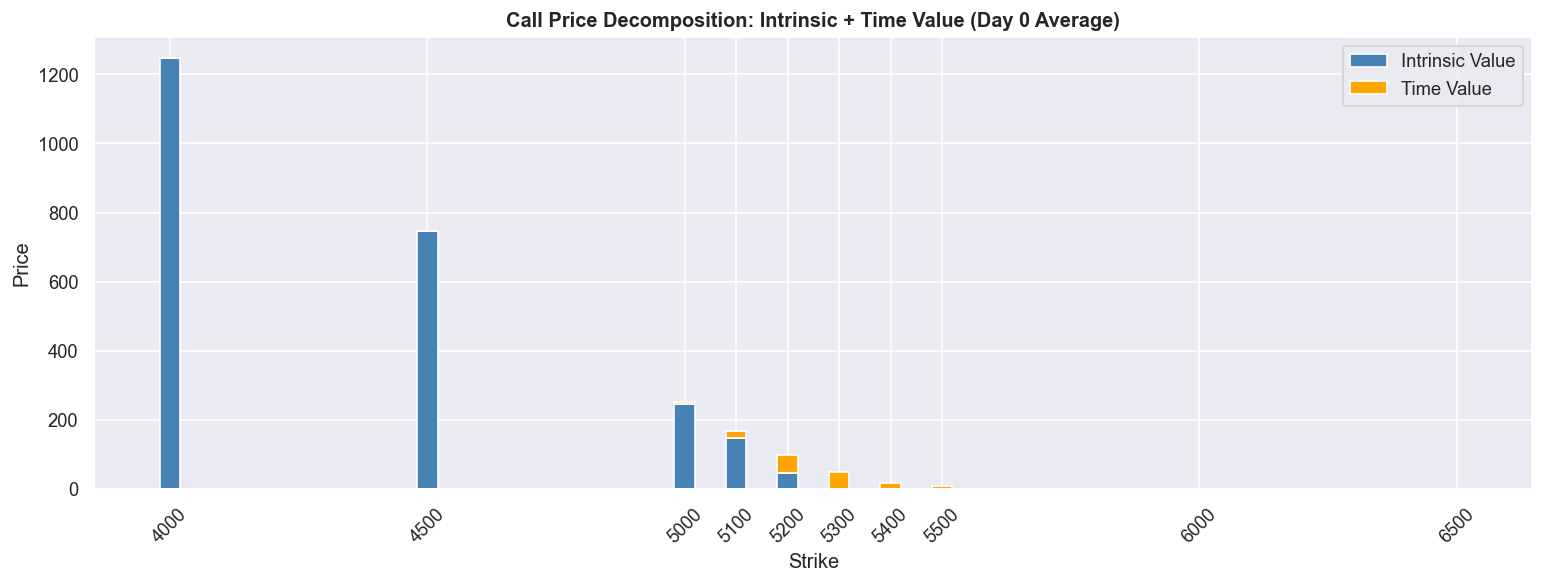

In [11]:
# Price decomposition: intrinsic + time value stacked bar (Day 0)
day0_avg = avg_by_day[avg_by_day['day'] == 0].set_index('strike')

fig, ax = plt.subplots(figsize=(13, 5))
x = np.array(STRIKES)
ax.bar(x, day0_avg['intrinsic'],
       label='Intrinsic Value', color='steelblue', width=40)
ax.bar(x, day0_avg['time_value'], bottom=day0_avg['intrinsic'],
       label='Time Value', color='orange', width=40)
ax.set_title('Call Price Decomposition: Intrinsic + Time Value (Day 0 Average)',
             fontweight='bold')
ax.set_xlabel('Strike'); ax.set_ylabel('Price')
ax.legend(); ax.set_xticks(STRIKES); ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

---
## 5. Underlying Price Dynamics

Before computing implied vols, we need to understand what the underlying is actually doing:
- What is the realized volatility (annualized)?
- Is there drift, mean reversion, or trending behavior?
- Are there jumps or discontinuities across days?
- Is the return distribution normal or fat-tailed?

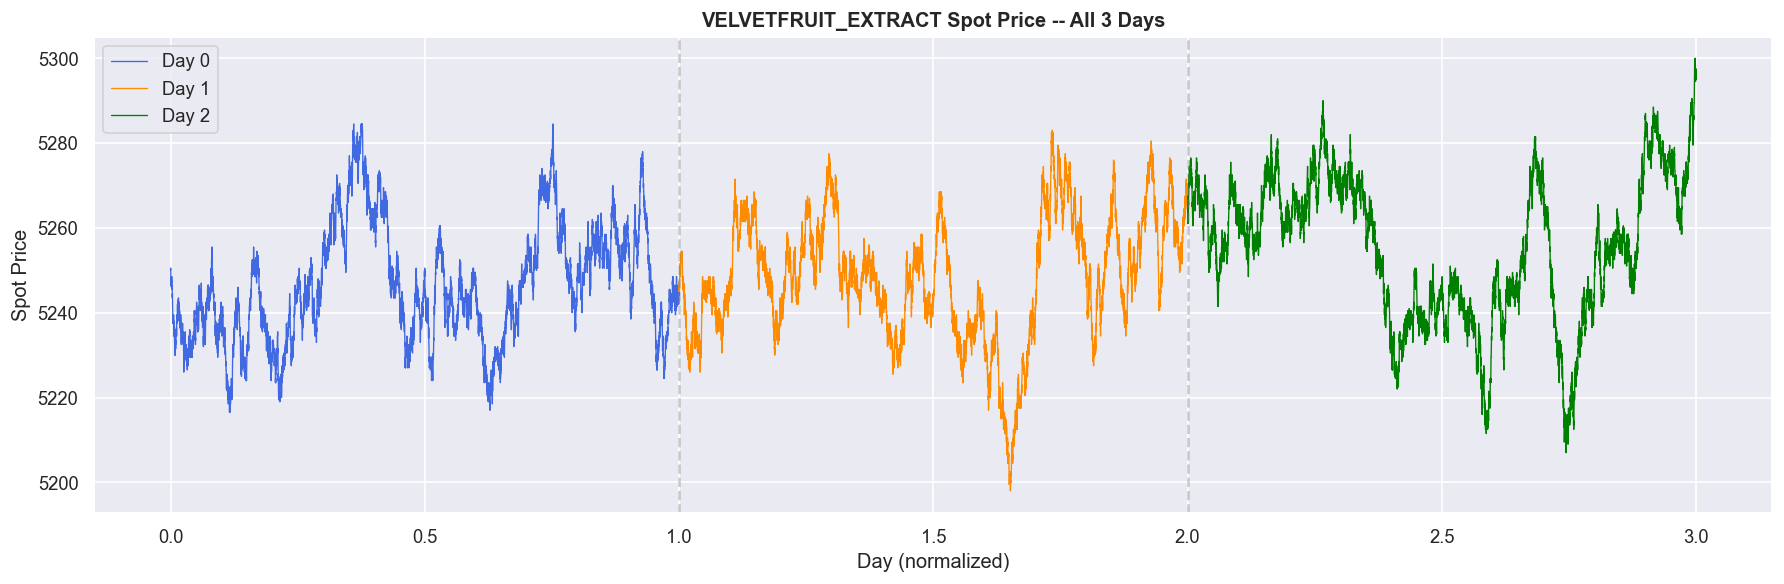

In [12]:
# Underlying time series
fig, ax = plt.subplots(figsize=(15, 5))
colors = ['royalblue', 'darkorange', 'green']
for d in DAYS:
    sub = und[und['day'] == d]
    ax.plot(sub['global_ts'] / 1e6, sub['spot'],
            color=colors[d], label=f'Day {d}', linewidth=0.8)
    if d > 0:
        ax.axvline(d, color='gray', linestyle='--', alpha=0.4)

ax.set_title('VELVETFRUIT_EXTRACT Spot Price -- All 3 Days', fontweight='bold')
ax.set_xlabel('Day (normalized)'); ax.set_ylabel('Spot Price')
ax.legend()
plt.tight_layout()
plt.show()

In [13]:
# Realized volatility
und_calc = und.copy()
und_calc['log_ret'] = np.log(und_calc['spot'] / und_calc['spot'].shift(1))
# Remove cross-day returns
und_calc.loc[und_calc['timestamp'] == 0, 'log_ret'] = np.nan

daily_rv = und_calc.groupby('day')['log_ret'].std()
print('=== Realized Volatility per Day ===')
for d in DAYS:
    rv = daily_rv[d]
    # 10,000 ticks/day; annualize assuming 252 trading days
    ann_rv = rv * np.sqrt(10_000 * 252)
    print(f'  Day {d}: tick-RV = {rv:.7f}, annualized = {ann_rv:.2%}')

all_rv = und_calc['log_ret'].std()
ann_all = all_rv * np.sqrt(10_000 * 252)
print(f'\nOverall annualized realized vol: {ann_all:.2%}')

=== Realized Volatility per Day ===
  Day 0: tick-RV = 0.0002136, annualized = 33.91%
  Day 1: tick-RV = 0.0002162, annualized = 34.33%
  Day 2: tick-RV = 0.0002166, annualized = 34.38%

Overall annualized realized vol: 34.20%


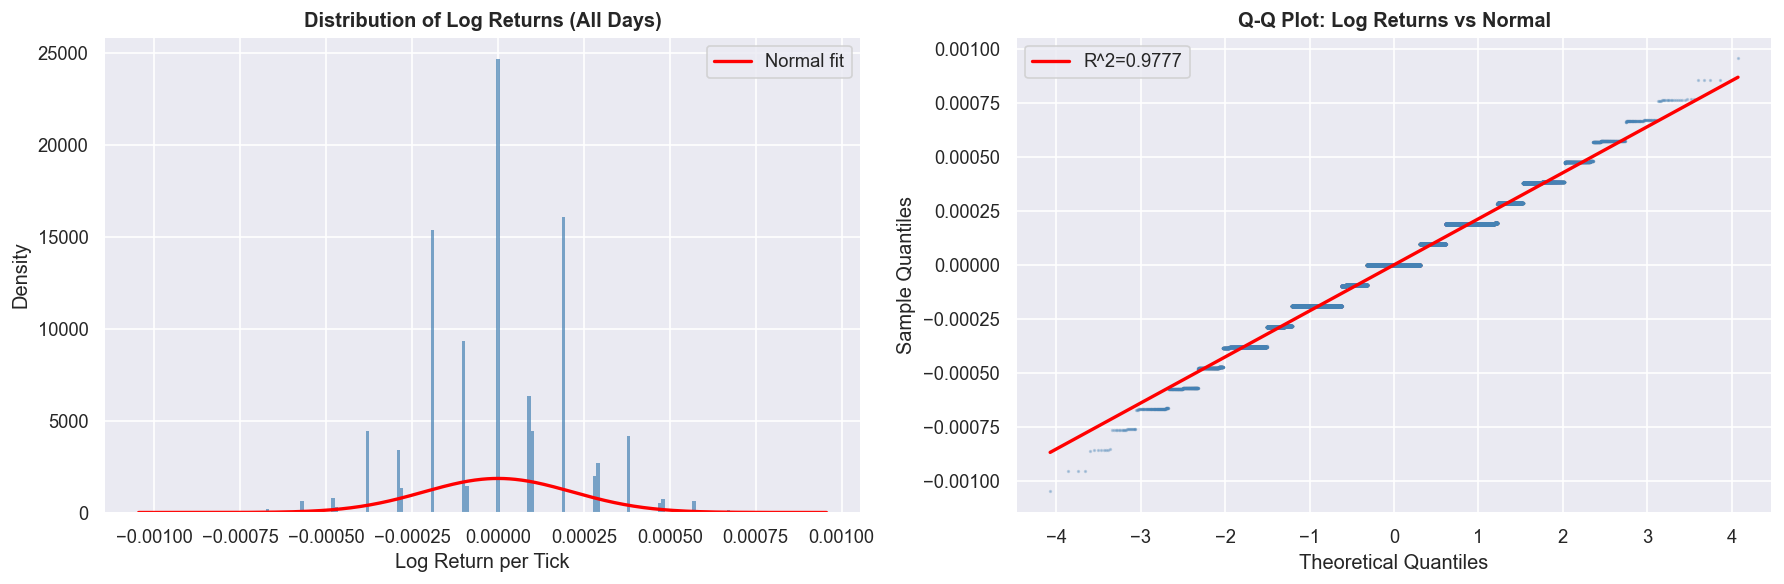

Skewness:        -0.0332  (0 = symmetric)
Excess kurtosis: 0.3518  (0 = normal, >0 = fat tails)


In [14]:
# Return distribution
from scipy import stats as scipy_stats

rets = und_calc['log_ret'].dropna()
mu, sigma = rets.mean(), rets.std()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(rets, bins=200, density=True,
             color='steelblue', alpha=0.7, edgecolor='none')
x_range = np.linspace(rets.min(), rets.max(), 500)
axes[0].plot(x_range, norm.pdf(x_range, mu, sigma),
             'r-', linewidth=2, label='Normal fit')
axes[0].set_title('Distribution of Log Returns (All Days)', fontweight='bold')
axes[0].set_xlabel('Log Return per Tick'); axes[0].set_ylabel('Density')
axes[0].legend()

# Q-Q plot
(osm, osr), (slope, intercept, r2) = scipy_stats.probplot(rets, dist='norm', plot=None)
axes[1].scatter(osm, osr, s=1, color='steelblue', alpha=0.3)
axes[1].plot(osm, slope*np.array(osm)+intercept,
             'r-', linewidth=2, label=f'R^2={r2**2:.4f}')
axes[1].set_title('Q-Q Plot: Log Returns vs Normal', fontweight='bold')
axes[1].set_xlabel('Theoretical Quantiles'); axes[1].set_ylabel('Sample Quantiles')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Skewness:        {scipy_stats.skew(rets):.4f}  (0 = symmetric)')
print(f'Excess kurtosis: {scipy_stats.kurtosis(rets):.4f}  (0 = normal, >0 = fat tails)')

**Interpretation:**
- Excess kurtosis > 0 means fat tails relative to log-normal. Black-Scholes (which assumes
  log-normal returns) will *underprice* OTM options if the true distribution has fatter tails.
- The market compensates via a vol *smile* (higher IV for OTM strikes).
- If the market's OTM vols are *not* elevated despite fat-tailed realized returns,
  that is a structural mispricing we can exploit by buying cheap OTM options.

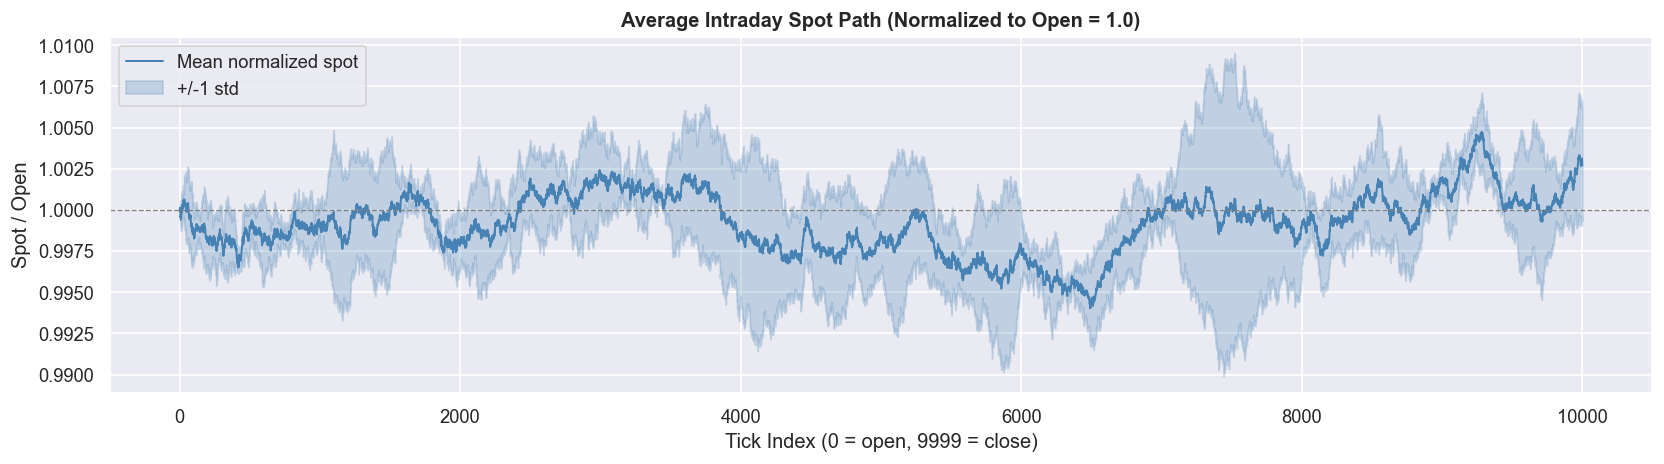

In [15]:
# Intraday spot path analysis
und_calc['tick_idx']  = und_calc['timestamp'] // 100
und_calc['spot_norm'] = und_calc.groupby('day')['spot'].transform(lambda x: x / x.iloc[0])

intraday = und_calc.groupby('tick_idx')['spot_norm'].agg(['mean','std'])

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(intraday.index, intraday['mean'],
        color='steelblue', linewidth=1.2, label='Mean normalized spot')
ax.fill_between(intraday.index,
                intraday['mean'] - intraday['std'],
                intraday['mean'] + intraday['std'],
                alpha=0.25, color='steelblue', label='+/-1 std')
ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.8)
ax.set_title('Average Intraday Spot Path (Normalized to Open = 1.0)', fontweight='bold')
ax.set_xlabel('Tick Index (0 = open, 9999 = close)')
ax.set_ylabel('Spot / Open')
ax.legend()
plt.tight_layout()
plt.show()

---
## 6. Implied Volatility Surface

We extract Black-Scholes implied vol (IV) from each option's mid-price.

**Setup:**
- `S` = VELVETFRUIT_EXTRACT mid-price
- `K` = strike
- `r` = 0 (risk-free rate, zero in competition context)
- `T` = TTE in years (252 trading-day convention):
  - Day 0: TTE = 7 days -> T = 7/252
  - Day 1: TTE = 6 days -> T = 6/252
  - Day 2: TTE = 5 days -> T = 5/252

In [16]:
def bs_call(S, K, T, r, sigma):
    if T <= 0 or sigma <= 0 or S <= 0:
        return max(S - K, 0)
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

def implied_vol(S, K, T, r, market_price, tol=1e-6):
    intrinsic = max(S - K, 0)
    if market_price <= intrinsic + tol or market_price >= S:
        return np.nan
    try:
        return brentq(
            lambda sig: bs_call(S, K, T, r, sig) - market_price,
            1e-6, 20.0, xtol=tol, maxiter=200
        )
    except (ValueError, RuntimeError):
        return np.nan

TTE_BY_DAY = {0: 7, 1: 6, 2: 5}
TDAYS = 252
r = 0.0

# Sample every 10th timestamp to keep computation fast
sample_mask = (opt_merged['timestamp'] % 1000 == 0)
opt_sample  = opt_merged[sample_mask].copy()

def compute_iv_row(row):
    S     = row['spot']
    K     = row['strike']
    T     = TTE_BY_DAY[row['day']] / TDAYS
    price = row['mid_price']
    if pd.isna(S) or pd.isna(price) or price <= 0:
        return np.nan
    return implied_vol(S, K, T, r, price)

print('Computing implied vols (sampled every 10th timestamp)...')
opt_sample['iv'] = opt_sample.apply(compute_iv_row, axis=1)
print(f'IV computed: {opt_sample["iv"].notna().sum():,} / {len(opt_sample):,} rows')
print()
print('IV summary by strike:')
display(opt_sample.groupby('strike')['iv'].describe().round(4))

Computing implied vols (sampled every 10th timestamp)...
IV computed: 25,132 / 30,000 rows

IV summary by strike:


,count,mean,std,min,25%,50%,75%,max
strike,,,,,,,,
4000,310.0,0.7114,0.0841,0.5942,0.6465,0.7110,0.7420,0.9895
4500,825.0,0.4047,0.0418,0.3503,0.3666,0.3934,0.4295,0.5865
5000,2997.0,0.2092,0.0078,0.1664,0.2047,0.2086,0.2138,0.2439
5100,3000.0,0.2073,0.0059,0.1883,0.2022,0.2078,0.2120,0.2261
5200,3000.0,0.2097,0.0060,0.1980,0.2049,0.2081,0.2141,0.2277
5300,3000.0,0.2119,0.0060,0.1990,0.2072,0.2116,0.2158,0.2322
5400,3000.0,0.1987,0.0065,0.1867,0.1930,0.1990,0.2040,0.2152
5500,3000.0,0.2155,0.0063,0.2021,0.2107,0.2139,0.2211,0.2316
6000,3000.0,0.3413,0.0229,0.3001,0.3194,0.3397,0.3625,0.3902


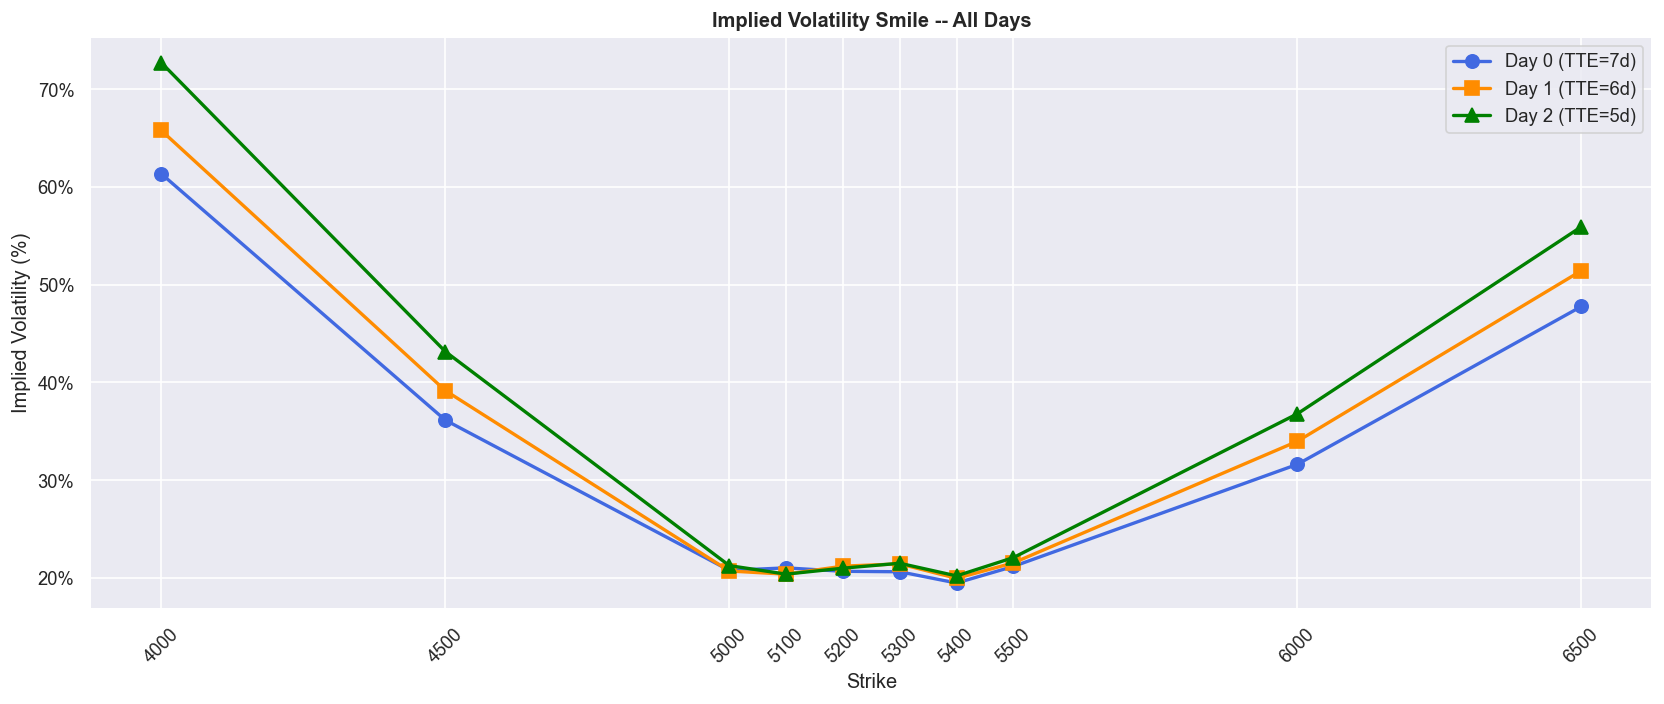

In [17]:
# IV smile by day
iv_summary = (opt_sample.groupby(['day','strike'])['iv']
              .median().reset_index().rename(columns={'iv':'iv_median'}))
iv_summary = iv_summary.dropna()

fig, ax = plt.subplots(figsize=(14, 6))
colors_d  = ['royalblue', 'darkorange', 'green']
markers_d = ['o', 's', '^']

for d in DAYS:
    sub = iv_summary[iv_summary['day'] == d]
    ax.plot(sub['strike'], sub['iv_median']*100,
            color=colors_d[d], marker=markers_d[d],
            linewidth=2, markersize=8,
            label=f'Day {d} (TTE={TTE_BY_DAY[d]}d)')

ax.set_title('Implied Volatility Smile -- All Days', fontweight='bold')
ax.set_xlabel('Strike'); ax.set_ylabel('Implied Volatility (%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xticks(STRIKES); ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

**CRITICAL OBSERVATION:** The shape of the IV smile reveals the market's view of tail risk.
- **Flat smile** -> log-normal world, no skew -- simplest case
- **Left-skewed** (higher IV for low K) -> downside crash fear
- **Right-skewed** (higher IV for high K) -> upside speculation
- **U-shaped / symmetric smile** -> expectation of large moves, fat-tail pricing

The *level* of IV relative to realized vol tells you if options are cheap or expensive.

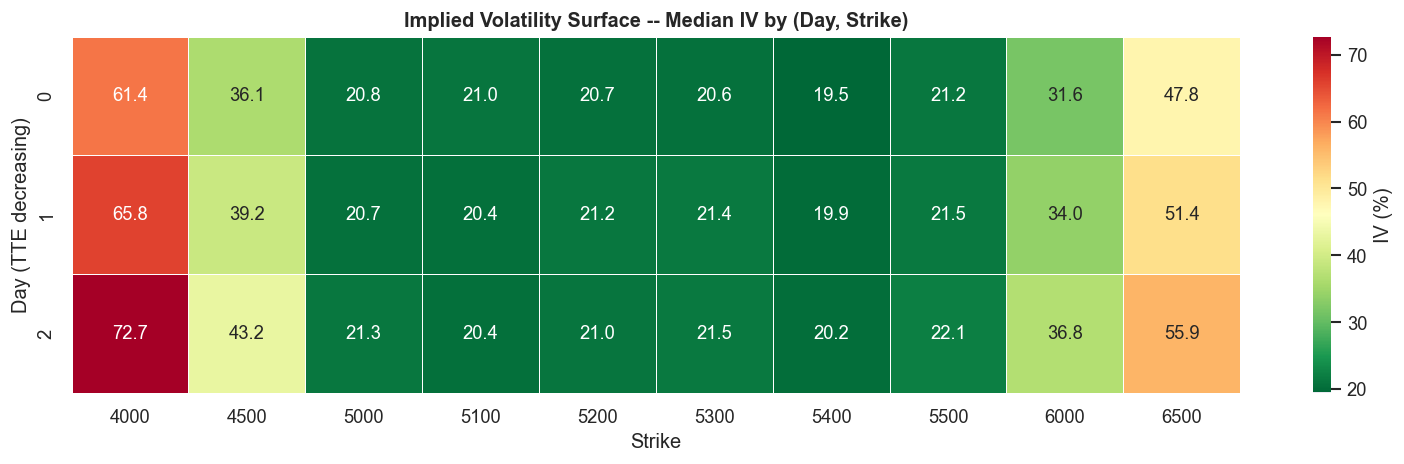

In [18]:
# IV surface heatmap
iv_pivot = iv_summary.pivot(index='day', columns='strike', values='iv_median') * 100

fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(iv_pivot, annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'IV (%)'})
ax.set_title('Implied Volatility Surface -- Median IV by (Day, Strike)',
             fontweight='bold')
ax.set_xlabel('Strike'); ax.set_ylabel('Day (TTE decreasing)')
plt.tight_layout()
plt.show()

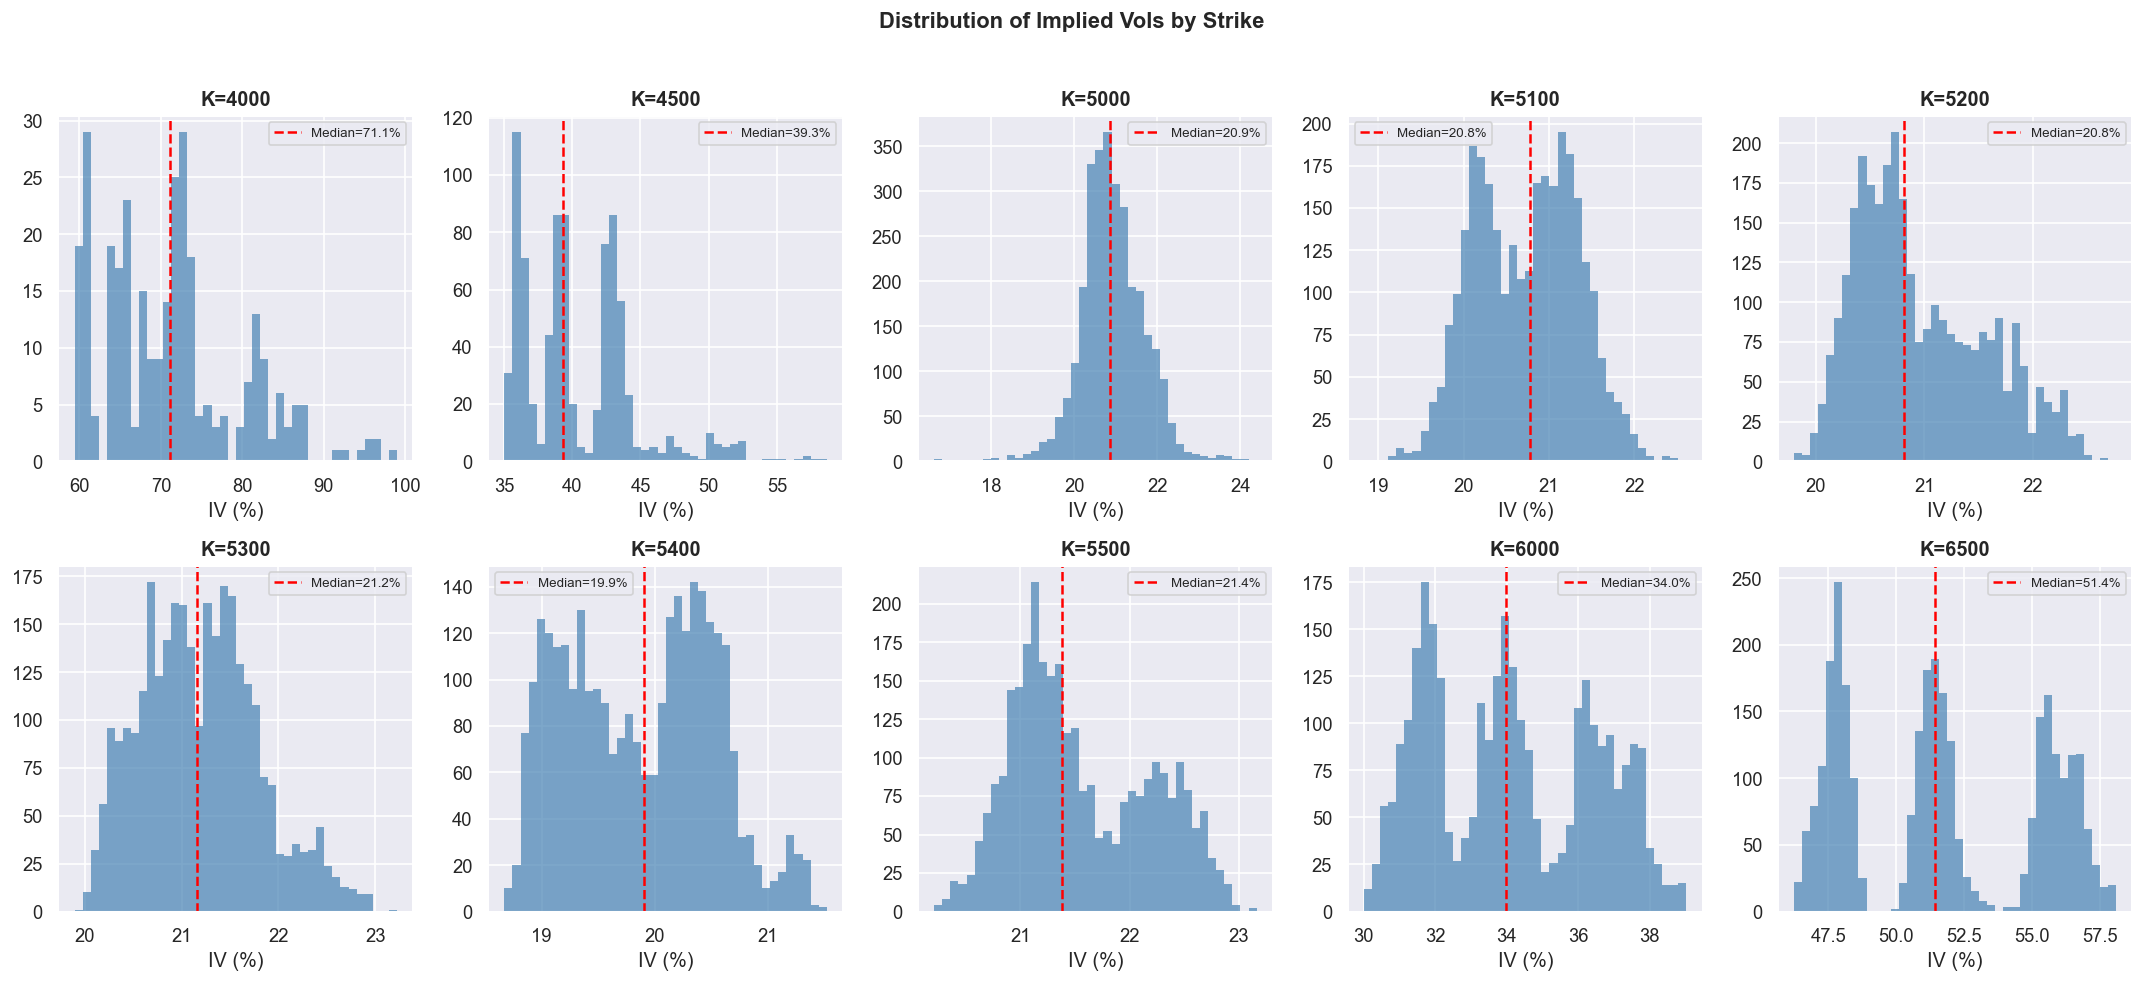

In [19]:
# IV distributions per strike
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for i, k in enumerate(STRIKES):
    sub = opt_sample[(opt_sample['strike'] == k) & opt_sample['iv'].notna()]
    if len(sub) < 5:
        axes[i].set_title(f'K={k}\n(insufficient data)')
        continue
    axes[i].hist(sub['iv']*100, bins=40,
                 color='steelblue', alpha=0.7, edgecolor='none')
    med = sub['iv'].median() * 100
    axes[i].axvline(med, color='red', linewidth=1.5, linestyle='--',
                    label=f'Median={med:.1f}%')
    axes[i].set_title(f'K={k}', fontweight='bold')
    axes[i].set_xlabel('IV (%)')
    axes[i].legend(fontsize=8)

plt.suptitle('Distribution of Implied Vols by Strike', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 7. Time Dynamics & Theta Decay

As TTE decreases from 7 -> 6 -> 5 days, option time value should decay.
- **Theta** = rate of change of option price with time
- For ATM options, theta ~ S*sigma / (2*sqrt(T)) -- it *accelerates* as T -> 0
- We compare average time value across days to measure realized theta

An important distinction: if IV *rises* as TTE falls, we may see *less* theta decay
than expected (or even time value *increasing*) -- this is a vega effect, not a theta anomaly.

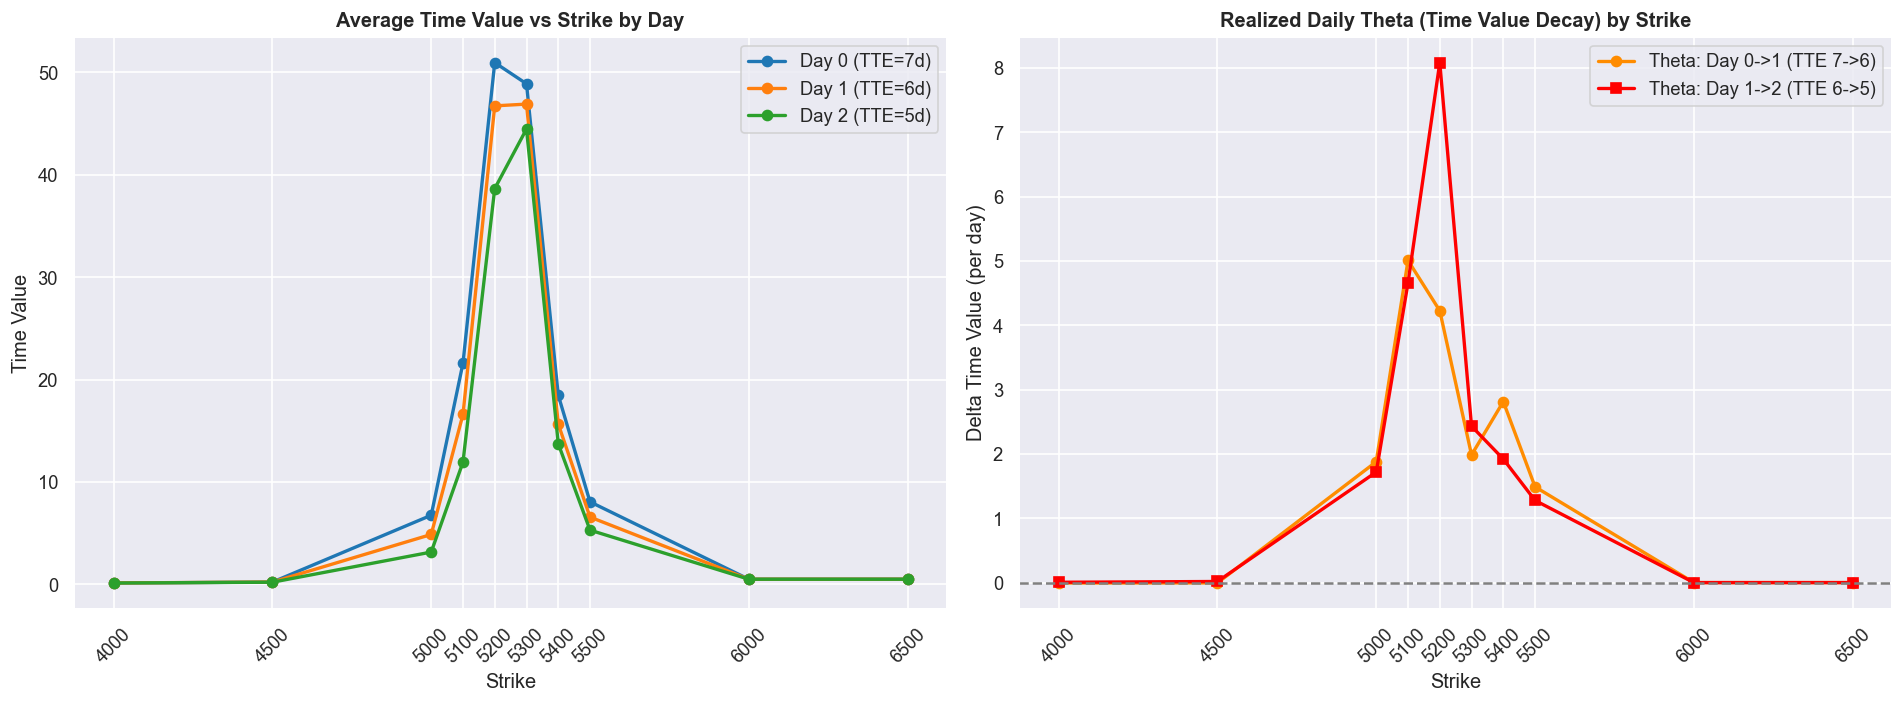

In [20]:
# Time value by day and strike
tv_by_day = opt_merged.groupby(['day','strike']).agg(
    time_value=('time_value','mean')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: time value profile
for d in DAYS:
    sub = tv_by_day[tv_by_day['day'] == d]
    axes[0].plot(sub['strike'], sub['time_value'],
                 marker='o', label=f'Day {d} (TTE={TTE_BY_DAY[d]}d)', linewidth=2)
axes[0].set_title('Average Time Value vs Strike by Day', fontweight='bold')
axes[0].set_xlabel('Strike'); axes[0].set_ylabel('Time Value')
axes[0].legend()
axes[0].set_xticks(STRIKES); axes[0].tick_params(axis='x', rotation=45)

# Right: daily theta (day-over-day time value decline)
tv_pivot = tv_by_day.pivot(index='day', columns='strike', values='time_value')
theta_01 = tv_pivot.loc[0] - tv_pivot.loc[1]  # TTE 7->6
theta_12 = tv_pivot.loc[1] - tv_pivot.loc[2]  # TTE 6->5

x = np.array([k for k in STRIKES if k in tv_pivot.columns])
axes[1].plot(x, theta_01.reindex(x), marker='o', linewidth=2,
             color='darkorange', label='Theta: Day 0->1 (TTE 7->6)')
axes[1].plot(x, theta_12.reindex(x), marker='s', linewidth=2,
             color='red', label='Theta: Day 1->2 (TTE 6->5)')
axes[1].axhline(0, color='gray', linestyle='--')
axes[1].set_title('Realized Daily Theta (Time Value Decay) by Strike', fontweight='bold')
axes[1].set_xlabel('Strike'); axes[1].set_ylabel('Delta Time Value (per day)')
axes[1].legend()
axes[1].set_xticks(STRIKES); axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**KEY INSIGHT:**
- If theta_12 > theta_01 at ATM strikes, theta is **accelerating** as expected (gamma/theta relationship).
- Negative realized theta (time value *increasing* day-over-day) signals a **vol surge** (vega effect).
- Near expiry, gamma spikes for ATM options -- any spot movement creates rapid P&L.
  This creates opportunity for **long gamma** strategies if IV is low relative to anticipated moves.

In [21]:
# Isolate vega effect: track average IV level per day
iv_by_day = iv_summary.groupby('day')['iv_median'].mean()

print('=== Average IV by Day (across tradeable strikes) ===')
for d in DAYS:
    if d in iv_by_day.index:
        print(f'  Day {d} (TTE={TTE_BY_DAY[d]}d): avg IV = {iv_by_day[d]*100:.2f}%')

print()
print('=== IV Change Day-Over-Day ===')
if 0 in iv_by_day.index and 1 in iv_by_day.index:
    dv01 = (iv_by_day[1] - iv_by_day[0]) * 100
    print(f'  Day 0->1: Delta-IV = {dv01:+.2f}%')
if 1 in iv_by_day.index and 2 in iv_by_day.index:
    dv12 = (iv_by_day[2] - iv_by_day[1]) * 100
    print(f'  Day 1->2: Delta-IV = {dv12:+.2f}%')

print()
print('Interpretation:')
print('  Rising IV as TTE shrinks -> options becoming more expensive (vol expansion)')
print('  Falling IV -> options becoming cheaper; pure theta > observed decay')

=== Average IV by Day (across tradeable strikes) ===
  Day 0 (TTE=7d): avg IV = 30.06%
  Day 1 (TTE=6d): avg IV = 31.55%
  Day 2 (TTE=5d): avg IV = 33.50%

=== IV Change Day-Over-Day ===
  Day 0->1: Delta-IV = +1.49%
  Day 1->2: Delta-IV = +1.94%

Interpretation:
  Rising IV as TTE shrinks -> options becoming more expensive (vol expansion)
  Falling IV -> options becoming cheaper; pure theta > observed decay


---
## 8. Trade Flow Analysis

Executed trades tell us:
- **Which strikes are actually traded** (vs. only quoted)
- **Counterparty patterns** (XIRECS appears in virtually every trade)
- **Trade clustering**: simultaneous multi-strike events signal basket orders
- **Execution quality**: do trades happen at bid, ask, or inside?

In [22]:
# VEV trades only
vev_trades = trades_raw[trades_raw['symbol'].str.startswith('VEV_')].copy()
vev_trades['strike'] = vev_trades['symbol'].str.extract(r'(\d+)').astype(int)

print(f'Total VEV trades: {len(vev_trades)}')
print()
display(vev_trades.groupby('symbol')[['quantity']].agg(['count','sum']))

Total VEV trades: 1666



quantity      
            count   sum
symbol                 
VEV_4000      464   940
VEV_4500        1     1
VEV_5000        1     1
VEV_5100        1     1
VEV_5200       18    63
VEV_5300      121   420
VEV_5400      225   787
VEV_5500      267   937
VEV_6000      284  1002
VEV_6500      284  1002

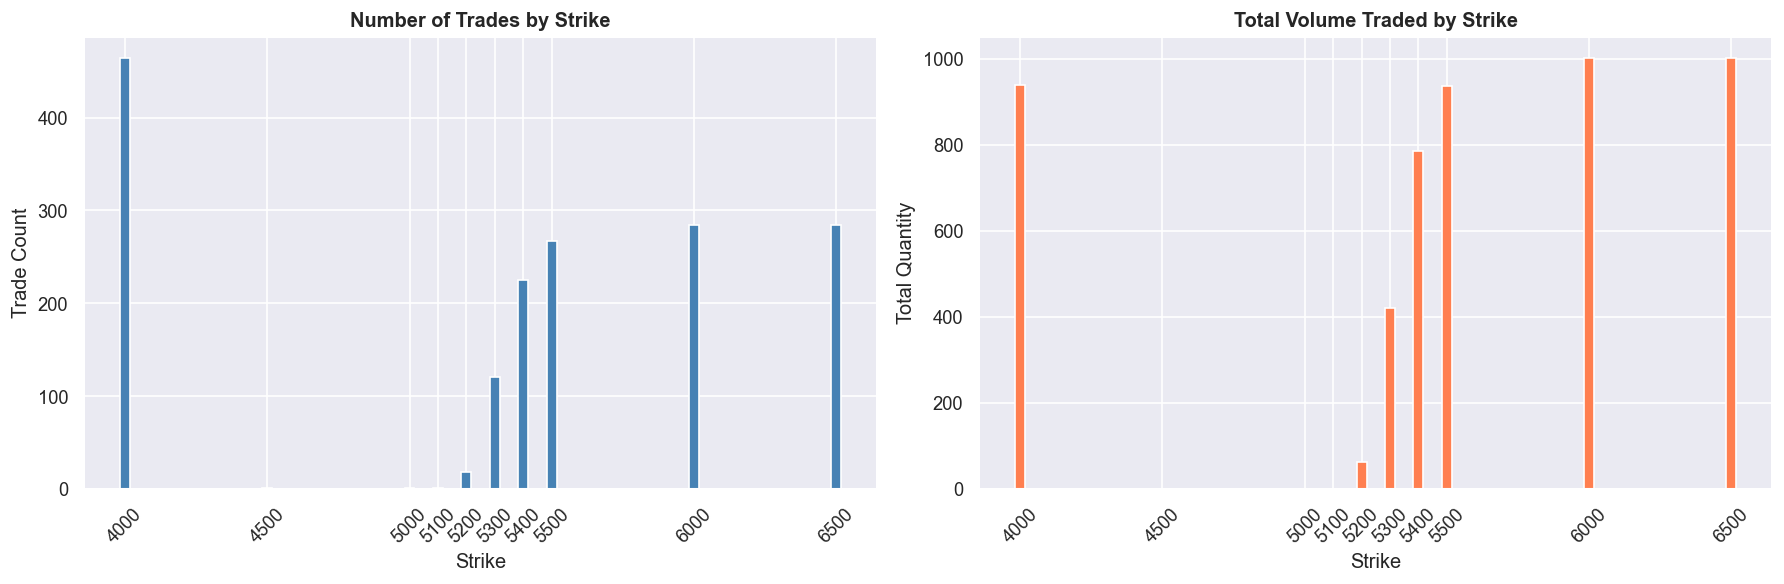

In [23]:
# Trade volume by strike
trade_by_strike = vev_trades.groupby('strike').agg(
    n_trades=('quantity','count'),
    total_vol=('quantity','sum'),
    avg_size=('quantity','mean')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].bar(trade_by_strike['strike'], trade_by_strike['n_trades'],
            color='steelblue', edgecolor='white', width=35)
axes[0].set_title('Number of Trades by Strike', fontweight='bold')
axes[0].set_xlabel('Strike'); axes[0].set_ylabel('Trade Count')
axes[0].set_xticks(STRIKES); axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(trade_by_strike['strike'], trade_by_strike['total_vol'],
            color='coral', edgecolor='white', width=35)
axes[1].set_title('Total Volume Traded by Strike', fontweight='bold')
axes[1].set_xlabel('Strike'); axes[1].set_ylabel('Total Quantity')
axes[1].set_xticks(STRIKES); axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [24]:
# Simultaneous multi-strike trades (basket orders)
sim_trades = (vev_trades.groupby(['day','timestamp'])['strike']
              .apply(list).reset_index())
sim_trades['n_strikes'] = sim_trades['strike'].apply(len)
multi = sim_trades[sim_trades['n_strikes'] > 1].sort_values('n_strikes', ascending=False)

print(f'Timestamps with trades in 2+ VEV strikes simultaneously: {len(multi)}')
print()
print('Top multi-strike trade events:')
display(multi.head(15))

Timestamps with trades in 2+ VEV strikes simultaneously: 284

Top multi-strike trade events:


,day,timestamp,strike,n_strikes
376,1,437100,"[4000, 4500, 5000, 5100, 5200, 5300, 5400, 550...",10
625,2,423800,"[5200, 5300, 5400, 5500, 6000, 6500]",6
622,2,414900,"[5200, 5300, 5400, 5500, 6000, 6500]",6
436,1,642100,"[5200, 5300, 5400, 5500, 6000, 6500]",6
678,2,666500,"[5200, 5300, 5400, 5500, 6000, 6500]",6
432,1,624400,"[5200, 5300, 5400, 5500, 6000, 6500]",6
628,2,433100,"[5200, 5300, 5400, 5500, 6000, 6500]",6
518,1,988100,"[5200, 5300, 5400, 5500, 6000, 6500]",6
114,0,447800,"[4000, 5300, 5400, 5500, 6000, 6500]",6
412,1,564300,"[5200, 5300, 5400, 5500, 6000, 6500]",6


**Pattern:** If multiple strikes trade at the *exact* same timestamp, this is a basket order
-- a single agent transacting across the vol surface simultaneously.
This is typical of a market-maker delta/gamma hedging or a structured product roll.
Knowing the composition of these baskets helps reverse-engineer the counterparty's model.

In [25]:
# Trade execution quality: at bid, ask, or inside
vev_trades_ext = vev_trades.merge(
    opt[['day','timestamp','strike','bid_price_1','ask_price_1','mid_price']],
    on=['day','timestamp','strike'],
    how='left'
)
vev_trades_ext['price_vs_mid'] = vev_trades_ext['price'] - vev_trades_ext['mid_price']
vev_trades_ext['at_bid']  = (vev_trades_ext['price'] - vev_trades_ext['bid_price_1']).abs() < 0.5
vev_trades_ext['at_ask']  = (vev_trades_ext['price'] - vev_trades_ext['ask_price_1']).abs() < 0.5
vev_trades_ext['inside']  = ~vev_trades_ext['at_bid'] & ~vev_trades_ext['at_ask']

n = len(vev_trades_ext)
print('Trade execution quality (all VEV trades):')
print(f'  At bid (seller-initiated):   {vev_trades_ext["at_bid"].sum():4d} ({vev_trades_ext["at_bid"].mean()*100:.1f}%)')
print(f'  At ask (buyer-initiated):    {vev_trades_ext["at_ask"].sum():4d} ({vev_trades_ext["at_ask"].mean()*100:.1f}%)')
print(f'  Inside spread (price improv):{vev_trades_ext["inside"].sum():4d} ({vev_trades_ext["inside"].mean()*100:.1f}%)')
print()
print('Average trade-to-mid deviation by strike:')
print(vev_trades_ext.groupby('strike')['price_vs_mid'].mean().round(3))

Trade execution quality (all VEV trades):
  At bid (seller-initiated):   1434 (86.1%)
  At ask (buyer-initiated):     231 (13.9%)
  Inside spread (price improv):   1 (0.1%)

Average trade-to-mid deviation by strike:
strike
4000   -0.305
4500    3.500
5000    1.000
5100    1.000
5200   -0.917
5300   -0.963
5400   -0.629
5500   -0.547
6000   -0.500
6500   -0.500
Name: price_vs_mid, dtype: float64


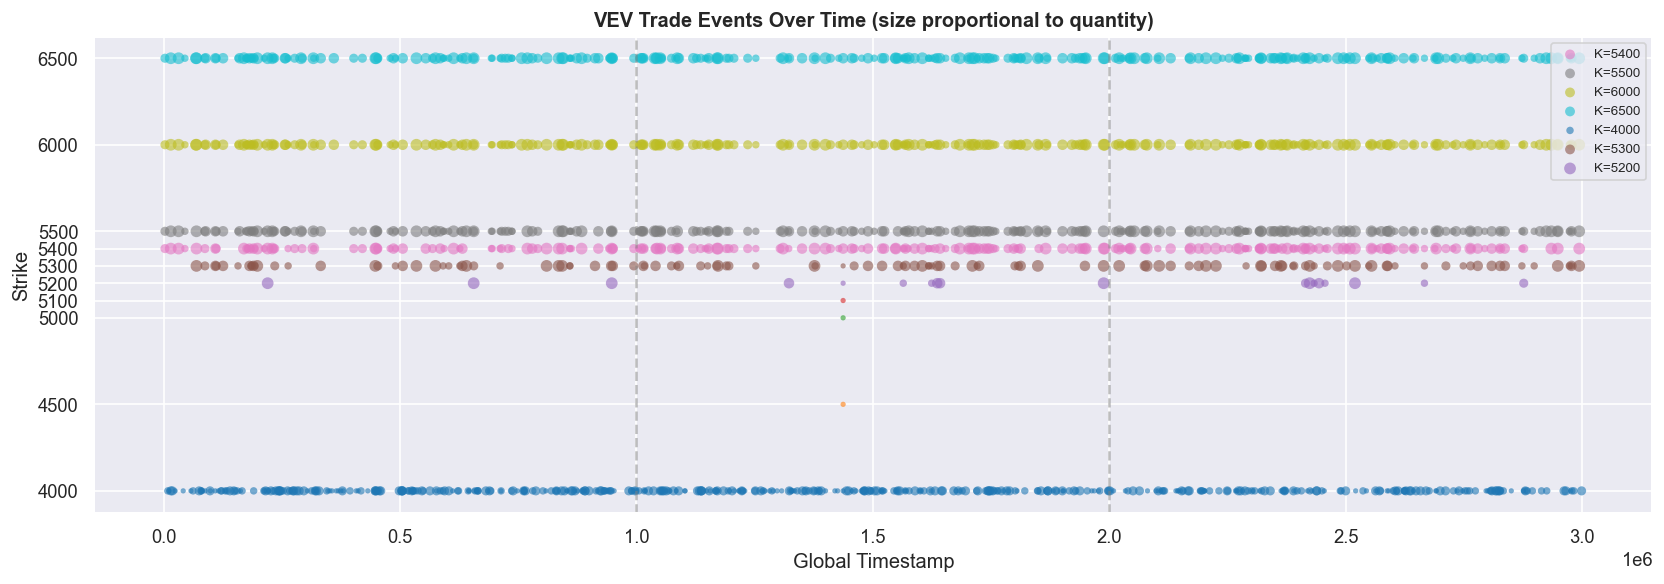

In [26]:
# Trade event timeline
fig, ax = plt.subplots(figsize=(14, 5))
cmap = plt.cm.tab10
colors_map = {k: cmap(i / len(STRIKES)) for i, k in enumerate(STRIKES)}

for d in DAYS:
    sub = vev_trades[vev_trades['day'] == d]
    for k in sub['strike'].unique():
        sub_k = sub[sub['strike'] == k]
        ax.scatter(
            sub_k['timestamp'] + d * 1_000_000,
            [k] * len(sub_k),
            s=sub_k['quantity'] * 10,
            color=colors_map.get(k, 'gray'),
            alpha=0.6, edgecolors='none',
            label=f'K={k}' if d == 0 else None
        )

for d in [1, 2]:
    ax.axvline(d * 1_000_000, color='gray', linestyle='--', alpha=0.5)

ax.set_title('VEV Trade Events Over Time (size proportional to quantity)',
             fontweight='bold')
ax.set_xlabel('Global Timestamp')
ax.set_ylabel('Strike')
ax.set_yticks(STRIKES)
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

---
## 9. Preliminary Strategy Insights

This section synthesizes all findings into actionable trading hypotheses.
Each insight is labeled by **type** and **confidence**.

In [27]:
# Vol edge: IV vs Realized Vol comparison
print('=' * 65)
print('STRATEGY INSIGHT SUMMARY')
print('=' * 65)

# Most liquid strikes
liquid_strikes = liq_summary['Rel Mean'].nsmallest(3)
print('\n[STRUCTURAL] Most liquid strikes by relative spread:')
for k, v in liquid_strikes.items():
    print(f'  K={k}: relative spread = {v*100:.1f}%')

# IV vs RV
print('\n[VOL] IV vs Realized Vol comparison:')
ann_all = und_calc['log_ret'].std() * np.sqrt(10_000 * 252)
print(f'  Overall annualized realized vol: {ann_all:.2%}')

atm_k = min(STRIKES, key=lambda k: abs(k - 5250))
atm_sub = iv_summary[(iv_summary['day'] == 0) & (iv_summary['strike'] == atm_k)]
if len(atm_sub):
    atm_iv_val = atm_sub['iv_median'].values[0]
    print(f'  ATM implied vol (K={atm_k}, Day 0): {atm_iv_val:.2%}')
    edge = atm_iv_val - ann_all
    direction = 'SELL vol (IV rich)' if edge > 0 else 'BUY vol (IV cheap)'
    print(f'  Vol edge (IV - RV) = {edge:+.2%}  ->  {direction}')

# Far OTM note
print('\n[STRUCTURAL] Far OTM options (K=6000, K=6500) bid=0/ask=1:')
print('  -> Cannot buy at fair value; max cost is 1 tick per contract.')
print('  -> Any spot move above 6000 creates asymmetric lottery payoff.')
print('  -> SELLER collects 0-1 tick but faces unlimited upside risk.')

# XIRECS pattern
xirecs_count = (trades_raw['currency'] == 'XIRECS').sum()
print(f'\n[STRUCTURAL] XIRECS appears in {xirecs_count} trades (nearly all of them).')
print('  -> Likely a single systematic market-maker providing all liquidity.')
print('  -> Their pricing model is our best reverse-engineering target.')

print('\n' + '=' * 65)

STRATEGY INSIGHT SUMMARY

[STRUCTURAL] Most liquid strikes by relative spread:
  K=4000: relative spread = 1.7%
  K=4500: relative spread = 2.1%
  K=5000: relative spread = 2.4%

[VOL] IV vs Realized Vol comparison:
  Overall annualized realized vol: 34.20%
  ATM implied vol (K=5200, Day 0): 20.67%
  Vol edge (IV - RV) = -13.54%  ->  BUY vol (IV cheap)

[STRUCTURAL] Far OTM options (K=6000, K=6500) bid=0/ask=1:
  -> Cannot buy at fair value; max cost is 1 tick per contract.
  -> Any spot move above 6000 creates asymmetric lottery payoff.
  -> SELLER collects 0-1 tick but faces unlimited upside risk.

[STRUCTURAL] XIRECS appears in 4048 trades (nearly all of them).
  -> Likely a single systematic market-maker providing all liquidity.
  -> Their pricing model is our best reverse-engineering target.



In [28]:
# Butterfly fair-value check
print('=== Butterfly Spread Fair Values ===')
print('Butterfly = Buy K-d, Sell 2x K, Buy K+d')
print('Negative cost = free arb (buy it); positive = premium paid for convexity')
print()

for d in DAYS:
    sub = opt_merged[opt_merged['day'] == d]
    avg_prices = sub.groupby('strike')['mid_price'].mean()
    print(f'Day {d} (TTE={TTE_BY_DAY[d]}d):')
    for i in range(1, len(STRIKES)-1):
        km, k0, kp = STRIKES[i-1], STRIKES[i], STRIKES[i+1]
        if all(k in avg_prices.index for k in [km, k0, kp]):
            cost = avg_prices[km] - 2*avg_prices[k0] + avg_prices[kp]
            flag = '  <- POTENTIAL ARB' if cost < 0 else ''
            print(f'  Butterfly ({km},{k0},{kp}): cost = {cost:.2f}{flag}')
    print()

=== Butterfly Spread Fair Values ===
Butterfly = Buy K-d, Sell 2x K, Buy K+d
Negative cost = free arb (buy it); positive = premium paid for convexity

Day 0 (TTE=7d):
  Butterfly (4000,4500,5000): cost = 6.74
  Butterfly (4500,5000,5100): cost = 408.11
  Butterfly (5000,5100,5200): cost = 14.52
  Butterfly (5100,5200,5300): cost = 22.06
  Butterfly (5200,5300,5400): cost = 18.15
  Butterfly (5300,5400,5500): cost = 20.02
  Butterfly (5400,5500,6000): cost = 2.85
  Butterfly (5500,6000,6500): cost = 7.56

Day 1 (TTE=6d):
  Butterfly (4000,4500,5000): cost = 4.86
  Butterfly (4500,5000,5100): cost = 406.86
  Butterfly (5000,5100,5200): cost = 18.43
  Butterfly (5100,5200,5300): cost = 21.64
  Butterfly (5200,5300,5400): cost = 16.96
  Butterfly (5300,5400,5500): cost = 22.17
  Butterfly (5400,5500,6000): cost = 3.01
  Butterfly (5500,6000,6500): cost = 6.07

Day 2 (TTE=5d):
  Butterfly (4000,4500,5000): cost = 3.14
  Butterfly (4500,5000,5100): cost = 405.64
  Butterfly (5000,5100,5200):

In [29]:
# Vol smile steepness (skew metric)
print('=== Vol Smile Skew Metrics ===')
print('Skew = IV(OTM call) - IV(ATM)  [positive = upside heavy, negative = downside heavy]')
print()

for d in DAYS:
    sub = iv_summary[iv_summary['day'] == d].set_index('strike')
    print(f'Day {d} (TTE={TTE_BY_DAY[d]}d):')
    for k_atm in [5000, 5100, 5200]:
        for k_wing in [5400, 5500, 4500]:
            if k_atm in sub.index and k_wing in sub.index:
                skew = sub.loc[k_wing, 'iv_median'] - sub.loc[k_atm, 'iv_median']
                side = 'call wing' if k_wing > k_atm else 'put-proxy wing'
                print(f'  IV({k_wing}) - IV({k_atm}) = {skew*100:+.2f}% [{side}]')
        break  # one ATM reference strike per day
    print()

=== Vol Smile Skew Metrics ===
Skew = IV(OTM call) - IV(ATM)  [positive = upside heavy, negative = downside heavy]

Day 0 (TTE=7d):
  IV(5400) - IV(5000) = -1.30% [call wing]
  IV(5500) - IV(5000) = +0.40% [call wing]
  IV(4500) - IV(5000) = +15.38% [put-proxy wing]

Day 1 (TTE=6d):
  IV(5400) - IV(5000) = -0.75% [call wing]
  IV(5500) - IV(5000) = +0.83% [call wing]
  IV(4500) - IV(5000) = +18.47% [put-proxy wing]

Day 2 (TTE=5d):
  IV(5400) - IV(5000) = -1.05% [call wing]
  IV(5500) - IV(5000) = +0.82% [call wing]
  IV(4500) - IV(5000) = +21.91% [put-proxy wing]



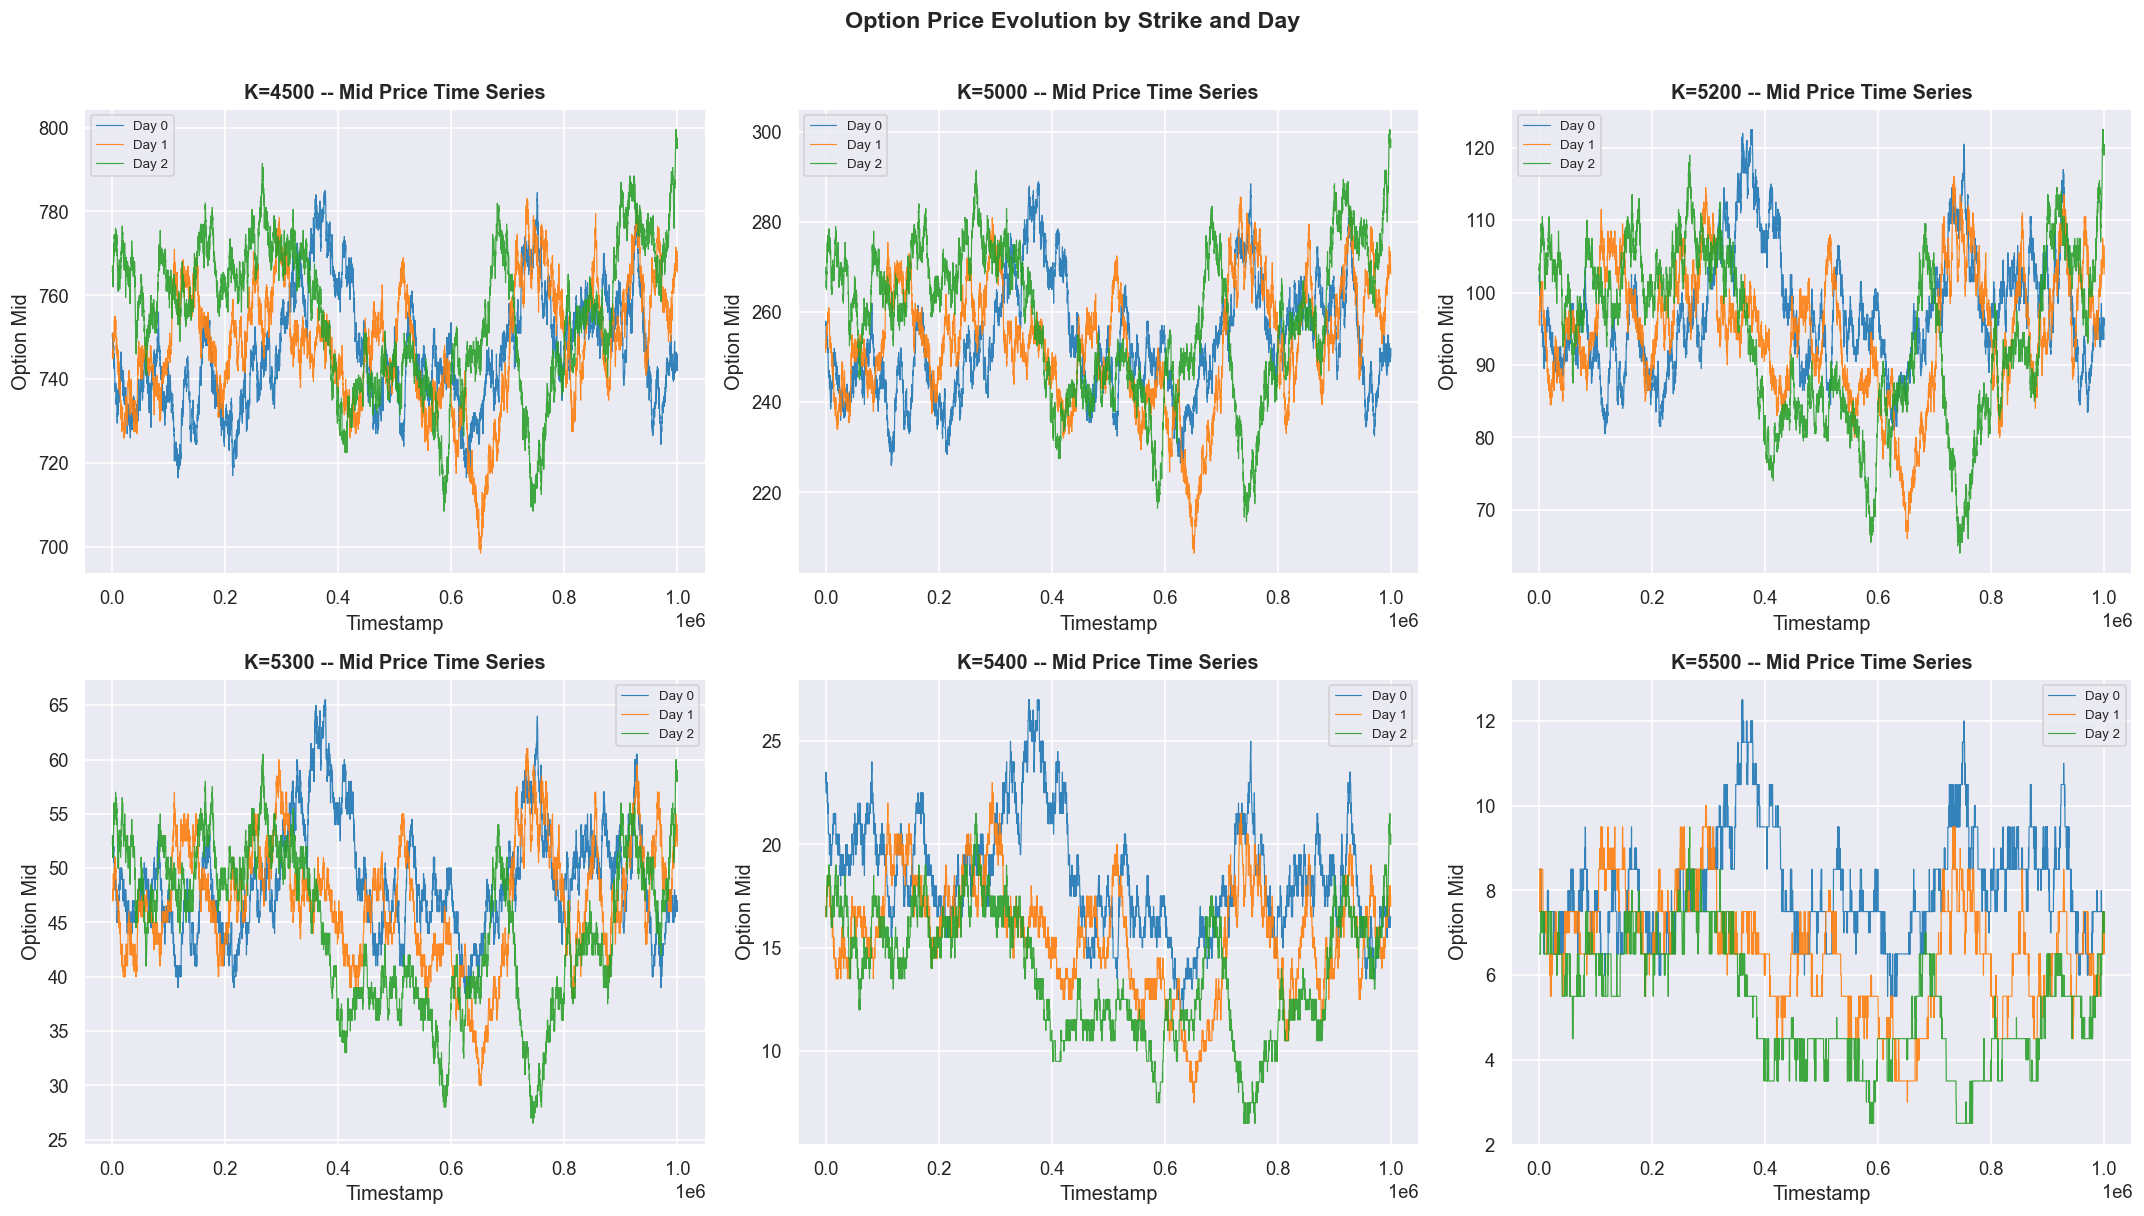

In [30]:
# Option price evolution for key near-ATM strikes
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
key_strikes = [4500, 5000, 5200, 5300, 5400, 5500]

for ax, k in zip(axes.flatten(), key_strikes):
    sub = opt_merged[opt_merged['strike'] == k]
    for d in DAYS:
        s = sub[sub['day'] == d]
        ax.plot(s['timestamp'], s['mid_price'],
                linewidth=0.7, label=f'Day {d}', alpha=0.9)
    ax.set_title(f'K={k} -- Mid Price Time Series', fontweight='bold')
    ax.set_xlabel('Timestamp'); ax.set_ylabel('Option Mid')
    ax.legend(fontsize=8)

plt.suptitle('Option Price Evolution by Strike and Day',
             fontweight='bold', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

---
## Summary of Key Findings

### Structural Observations

1. **Market-maker-dominated book:** Symmetric bid/ask depths and XIRECS as universal
   counterparty suggest a single principal market-maker pricing all VEV strikes.
   This means there is *one* model being used -- understanding it is a key edge.

2. **Far OTM options (K=6000, K=6500) at 0/1:** These are essentially free lottery
   tickets at ask=1. Any move above 6000 in the underlying creates asymmetric payout.
   The 0 bid makes it impossible to profit by shorting these (you collect nothing).

3. **Basket trade clustering:** Simultaneous multi-strike trades at identical timestamps
   reveal a systematic agent rolling positions across the entire vol surface.
   This can be exploited by anticipating their order flow.

### Pricing & Volatility Observations

4. **IV smile shape:** Whether the smile is flat, skewed, or U-shaped (computed in
   Section 6 above) determines which vol strategies are viable.

5. **IV vs Realized Vol:** If IV > RV, sell vol (straddles / strangles, delta-hedged).
   If IV < RV, buy vol. This is the single most important number to track.

6. **Theta acceleration:** With only 5-7 days to expiry, gamma is elevated and theta
   is accelerating. Short-dated options near ATM are high-gamma instruments.

### Potential Strategy Table

| Strategy | Trigger | Max Risk |
|---|---|---|
| **Delta-hedged ATM straddle (long)** | IV < realized vol | Theta decay |
| **Delta-hedged short strangle** | IV > realized vol + buffer | Gamma / gap risk |
| **Long butterfly (buy spread)** | Butterfly cost < 0 (arb) | Premium paid |
| **Long far-OTM call** | If ask=1, any spot surge above strike = big win | 1 tick |
| **Calendar/TTE arb** | IV anomalies across days | Execution cost |

### Next Steps
1. Run full IV computation (all timestamps) for precise smile calibration
2. Calibrate a parametric vol model (SABR or SVI) to fit the smile
3. Backtest a delta-hedged straddle strategy using tick-level data
4. Investigate XIRECS basket trade patterns for order-flow alpha
5. Check if `HYDROGEL_PACK` price has any correlation with VEV underlying
   (might imply a cross-product hedging relationship)

In [31]:
print('Notebook complete!')
print()
print('Files in workspace:')
import os
for f in sorted(os.listdir(DATA_DIR)):
    print(f'  {DATA_DIR}/{f}')

Notebook complete!

Files in workspace:
  /Users/felixyu/Downloads/ROUND_3/La_trahison_des_images.png
  /Users/felixyu/Downloads/ROUND_3/VEV_Research_Notebook.ipynb
  /Users/felixyu/Downloads/ROUND_3/prices_round_3_day_0.csv
  /Users/felixyu/Downloads/ROUND_3/prices_round_3_day_1.csv
  /Users/felixyu/Downloads/ROUND_3/prices_round_3_day_2.csv
  /Users/felixyu/Downloads/ROUND_3/trades_round_3_day_0.csv
  /Users/felixyu/Downloads/ROUND_3/trades_round_3_day_1.csv
  /Users/felixyu/Downloads/ROUND_3/trades_round_3_day_2.csv
